# Mini Machine Learning Project

## Project Question

Can we predict whether a customer is likely to make a repeat purchase?

## 1. Project Goal

The goal of this mini machine learning project is to predict whether a customer is likely to make a repeat purchase.

This is a classification problem because the model predicts one of two outcomes: reorder or not reorder.

The project follows the full machine learning cycle, including data loading, data cleaning, feature preparation, train/test split, preprocessing, model training, model evaluation, and business interpretation.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

## 3. Load the Data

In this step, I checked the available raw data files and loaded the dataset that will be used for the machine learning project.

In [6]:
import os

os.listdir("../data/raw")

['customers.csv',
 'orders.csv',
 'order_items.csv',
 'products.csv',
 'transactions.csv']

In [3]:
import os

os.listdir("../data/raw")

['customers.csv',
 'orders.csv',
 'order_items.csv',
 'products.csv',
 'transactions.csv']

In [9]:
import os

os.getcwd()

'c:\\Users\\homam\\OneDrive\\Desktop\\intern-bootcamp\\06_ml'

In [11]:
import os

os.listdir("../data/raw")

['customers.csv',
 'orders.csv',
 'order_items.csv',
 'products.csv',
 'transactions.csv']

In [12]:
import pandas as pd

customers = pd.read_csv("../data/raw/customers.csv")
orders = pd.read_csv("../data/raw/orders.csv")
order_items = pd.read_csv("../data/raw/order_items.csv")
products = pd.read_csv("../data/raw/products.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")

In [13]:
customers.head()

,customer_id,first_name,email,city,signup_date
0,1,Customer1,customer1@example.com,Abu Dhabi,2025-09-22 17:14:47.542946
1,2,Customer2,customer2@example.com,Ajman,2025-11-21 17:14:47.542968
2,3,Customer3,customer3@example.com,Abu Dhabi,2026-02-21 17:14:47.542973
3,4,Customer4,customer4@example.com,Sharjah,2025-10-09 17:14:47.542977
4,5,Customer5,customer5@example.com,Dubai,2025-07-22 17:14:47.542982


In [14]:
orders.head()

,order_id,customer_id,order_date,status
0,1,25,2026-01-04 17:14:47.555098,completed
1,2,27,2026-02-08 17:14:47.555110,completed
2,3,63,2026-03-25 17:14:47.555115,completed
3,4,93,2026-02-20 17:14:47.555118,cancelled
4,5,81,2025-11-28 17:14:47.555122,pending


In [15]:
orders["status"].value_counts()

status
completed    70
cancelled    66
pending      64
Name: count, dtype: int64

In [16]:
completed_orders = orders[orders["status"] == "completed"]

completed_orders.head()

,order_id,customer_id,order_date,status
0,1,25,2026-01-04 17:14:47.555098,completed
1,2,27,2026-02-08 17:14:47.555110,completed
2,3,63,2026-03-25 17:14:47.555115,completed
8,9,28,2026-02-07 17:14:47.555131,completed
11,12,70,2025-12-21 17:14:47.555136,completed


In [17]:
customer_order_counts = completed_orders.groupby("customer_id").size().reset_index(name="completed_order_count")

customer_order_counts.head()

,customer_id,completed_order_count
0,3,1
1,10,1
2,13,1
3,14,1
4,16,1


In [19]:
import pandas as pd

df = pd.read_csv("../data/processed/features_large.csv")

df.head()

,num__total_orders,num__total_spent,num__successful_payments,num__average_order_amount,will_reorder,cat__city_Abu Dhabi,cat__city_Ajman,cat__city_Dubai,cat__city_Sharjah
0,7,4739.61,5,677.09,1,False,False,False,True
1,20,1719.83,0,85.99,0,False,False,False,True
2,29,3638.66,9,125.47,1,False,True,False,False
3,15,2717.12,28,181.14,1,True,False,False,False
4,11,350.11,13,31.83,0,True,False,False,False


In [21]:
import os

os.listdir("../data/processed")

['customers_clean.parquet',
 'features.csv',
 'features_large.csv',
 'logs',
 'orders_clean.parquet',
 'order_items_clean.parquet',
 'products_clean.parquet',
 'transactions_clean.parquet']

In [23]:
import pandas as pd

df = pd.read_csv("../data/processed/features_large.csv")

df.head()

,num__total_orders,num__total_spent,num__successful_payments,num__average_order_amount,will_reorder,cat__city_Abu Dhabi,cat__city_Ajman,cat__city_Dubai,cat__city_Sharjah
0,7,4739.61,5,677.09,1,False,False,False,True
1,20,1719.83,0,85.99,0,False,False,False,True
2,29,3638.66,9,125.47,1,False,True,False,False
3,15,2717.12,28,181.14,1,True,False,False,False
4,11,350.11,13,31.83,0,True,False,False,False


In [25]:
df.shape

(5000, 9)

In [27]:
df.head()

,num__total_orders,num__total_spent,num__successful_payments,num__average_order_amount,will_reorder,cat__city_Abu Dhabi,cat__city_Ajman,cat__city_Dubai,cat__city_Sharjah
0,7,4739.61,5,677.09,1,False,False,False,True
1,20,1719.83,0,85.99,0,False,False,False,True
2,29,3638.66,9,125.47,1,False,True,False,False
3,15,2717.12,28,181.14,1,True,False,False,False
4,11,350.11,13,31.83,0,True,False,False,False


In [29]:
df.columns

Index(['num__total_orders', 'num__total_spent', 'num__successful_payments',
       'num__average_order_amount', 'will_reorder', 'cat__city_Abu Dhabi',
       'cat__city_Ajman', 'cat__city_Dubai', 'cat__city_Sharjah'],
      dtype='str')

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   num__total_orders          5000 non-null   int64  
 1   num__total_spent           5000 non-null   float64
 2   num__successful_payments   5000 non-null   int64  
 3   num__average_order_amount  5000 non-null   float64
 4   will_reorder               5000 non-null   int64  
 5   cat__city_Abu Dhabi        5000 non-null   bool   
 6   cat__city_Ajman            5000 non-null   bool   
 7   cat__city_Dubai            5000 non-null   bool   
 8   cat__city_Sharjah          5000 non-null   bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 215.0 KB


In [31]:
df.isnull().sum()

num__total_orders            0
num__total_spent             0
num__successful_payments     0
num__average_order_amount    0
will_reorder                 0
cat__city_Abu Dhabi          0
cat__city_Ajman              0
cat__city_Dubai              0
cat__city_Sharjah            0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

## 4. Data Quality Check

The dataset contains 5000 rows and 9 columns.  
I checked the data types, missing values, and duplicate rows before training the model.

The dataset has no missing values and no duplicate rows, so it is ready for the next machine learning steps.

In [33]:
df["will_reorder"].value_counts()

will_reorder
1    3407
0    1593
Name: count, dtype: int64

In [34]:
df["will_reorder"].value_counts(normalize=True)

will_reorder
1    0.6814
0    0.3186
Name: proportion, dtype: float64

## 5. Target Distribution

The target column is `will_reorder`.

The dataset contains 3407 customers who will reorder and 1593 customers who will not reorder.  
This means around 68% of the customers are repeat customers and around 32% are not repeat customers.

The target is not perfectly balanced, so I will evaluate the model using accuracy, precision, recall, and F1-score instead of accuracy only.

In [35]:
X = df.drop("will_reorder", axis=1)
y = df["will_reorder"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 8)
y shape: (5000,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 8)
X_test shape: (1000, 8)
y_train shape: (4000,)
y_test shape: (1000,)


## 6. Train/Test Split

I split the dataset into training and testing sets.

The training set contains 80% of the data and is used to train the model.  
The testing set contains 20% of the data and is used to evaluate how well the model performs on unseen data.

I used stratify=y to keep the same target balance in both the training and testing sets.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on unseen test data
    y_pred = model.predict(X_test)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Save results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.834,0.858136,0.906021,0.881429
1,Decision Tree,1.000,1.000000,1.000000,1.000000
2,Random Forest,1.000,1.000000,1.000000,1.000000


In [39]:
best_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,num__successful_payments,0.340798
0,num__total_orders,0.288039
1,num__total_spent,0.216321
3,num__average_order_amount,0.153290
7,cat__city_Sharjah,0.000473
6,cat__city_Dubai,0.000449
5,cat__city_Ajman,0.000338
4,cat__city_Abu Dhabi,0.000291


## 8. Feature Importance

The Random Forest model showed that the most important features were `num_successful_payments`, `num_total_orders`, `num_total_spent`, and `num_average_order_amount`.

This means the model mainly used customer purchase behavior to predict whether the customer is likely to reorder.

The city columns had very low importance, meaning customer location did not strongly affect the prediction in this dataset.

Because some features, such as total orders and successful payments, are strongly connected to repeat purchase behavior, the very high model score should be interpreted carefully.

In [40]:
best_model = models["Random Forest"]

y_pred_best = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Confusion Matrix:
[[319   0]
 [  0 681]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       319
           1       1.00      1.00      1.00       681

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [41]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())

Cross-validation scores: [1. 1. 1. 1. 1.]
Average CV accuracy: 1.0


In [45]:
print(type(df))
print(df.columns.tolist())

<class 'pandas.DataFrame'>
['num__total_orders', 'num__total_spent', 'num__successful_payments', 'num__average_order_amount', 'will_reorder', 'cat__city_Abu Dhabi', 'cat__city_Ajman', 'cat__city_Dubai', 'cat__city_Sharjah']


In [46]:
columns_to_remove = ["will_reorder", "num_total_orders", "num_successful_payments"]

for col in columns_to_remove:
    print(col, col in df.columns)

will_reorder True
num_total_orders False
num_successful_payments False


In [47]:
X_realistic = df.drop(columns=["will_reorder", "num__total_orders", "num__successful_payments"])

y = df["will_reorder"]

X_realistic.head()

,num__total_spent,num__average_order_amount,cat__city_Abu Dhabi,cat__city_Ajman,cat__city_Dubai,cat__city_Sharjah
0,4739.61,677.09,False,False,False,True
1,1719.83,85.99,False,False,False,True
2,3638.66,125.47,False,True,False,False
3,2717.12,181.14,True,False,False,False
4,350.11,31.83,True,False,False,False


In [48]:
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_realistic,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_real shape:", X_train_real.shape)
print("X_test_real shape:", X_test_real.shape)
print("y_train_real shape:", y_train_real.shape)
print("y_test_real shape:", y_test_real.shape)

X_train_real shape: (4000, 6)
X_test_real shape: (1000, 6)
y_train_real shape: (4000,)
y_test_real shape: (1000,)


In [49]:
realistic_results = []

for model_name, model in models.items():
    # Train the model using the realistic features
    model.fit(X_train_real, y_train_real)
    
    # Predict on unseen realistic test data
    y_pred_real = model.predict(X_test_real)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_real, y_pred_real)
    precision = precision_score(y_test_real, y_pred_real)
    recall = recall_score(y_test_real, y_pred_real)
    f1 = f1_score(y_test_real, y_pred_real)
    
    # Save results
    realistic_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

realistic_results_df = pd.DataFrame(realistic_results)
realistic_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.852,0.842105,0.963289,0.898630
1,Decision Tree,0.805,0.870427,0.838473,0.854151
2,Random Forest,0.875,0.874663,0.953010,0.912157


## 10. Realistic Model Experiment

The first experiment used all available features and achieved 100% accuracy.  
However, this result was very high because features such as `num__total_orders` and `num__successful_payments` are strongly connected to the target `will_reorder`.

To make the project more realistic, I created a second experiment by removing these two direct features.

After removing them, the model performance decreased, which is expected because the prediction problem became harder.  
The Random Forest model achieved the best result in the second experiment, with 87.5% accuracy and an F1-score of 91.2%.

This result is more realistic and shows that the model can still make strong predictions even without the most obvious customer behavior columns.

In [50]:
best_realistic_model = models["Random Forest"]

y_pred_real_best = best_realistic_model.predict(X_test_real)

print("Confusion Matrix:")
print(confusion_matrix(y_test_real, y_pred_real_best))

print("\nClassification Report:")
print(classification_report(y_test_real, y_pred_real_best))

Confusion Matrix:
[[226  93]
 [ 32 649]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.78       319
           1       0.87      0.95      0.91       681

    accuracy                           0.88      1000
   macro avg       0.88      0.83      0.85      1000
weighted avg       0.88      0.88      0.87      1000



## 11. Final Model Evaluation

The final realistic model was the Random Forest model.

The confusion matrix showed that the model correctly predicted 226 customers who would not reorder and 649 customers who would reorder.  
It made 93 false positive predictions and 32 false negative predictions.

The model achieved 88% accuracy overall.

For customers who will reorder, the model achieved 87% precision, 95% recall, and a 91% F1-score.  
This means the model is strong at identifying customers who are likely to make a repeat purchase.

For customers who will not reorder, the model achieved 88% precision, 71% recall, and a 78% F1-score.  
This means the model is less accurate at identifying customers who will not reorder.

From a business perspective, this model can help identify customers who are likely to buy again, which can support customer retention, marketing campaigns, and personalized offers.

In [51]:
realistic_feature_importance = pd.DataFrame({
    "Feature": X_realistic.columns,
    "Importance": best_realistic_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

realistic_feature_importance

,Feature,Importance
1,num__average_order_amount,0.523395
0,num__total_spent,0.471707
4,cat__city_Dubai,0.001421
5,cat__city_Sharjah,0.001264
2,cat__city_Abu Dhabi,0.001162
3,cat__city_Ajman,0.001051


## 12. Realistic Feature Importance

After removing the most direct features, the Random Forest model mainly depended on `num__average_order_amount` and `num__total_spent`.

The city columns had very low importance, which means customer location did not strongly affect repeat purchase prediction in this dataset.

This suggests that customer spending behavior is more useful than city information when predicting whether a customer is likely to reorder.

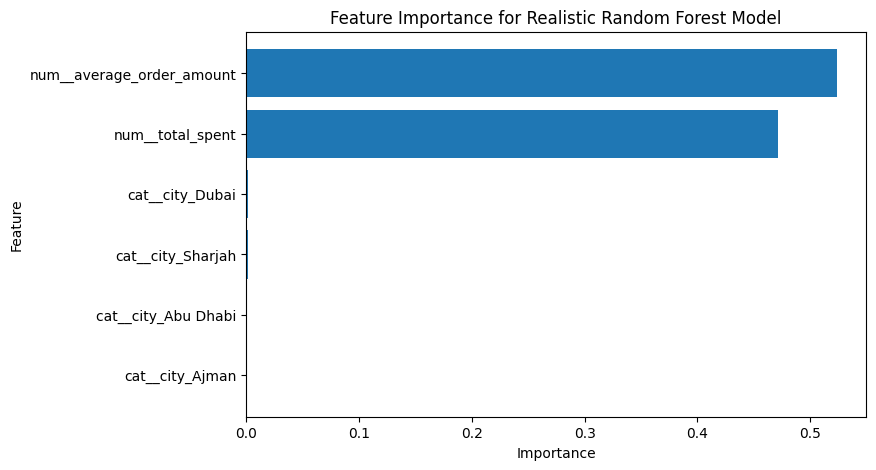

In [52]:
plt.figure(figsize=(8, 5))
plt.barh(realistic_feature_importance["Feature"], realistic_feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Realistic Random Forest Model")
plt.gca().invert_yaxis()
plt.show()

## 13. Final Conclusion

This mini machine learning project predicted whether a customer is likely to make a repeat purchase.

The project first tested three models using all available features. The Decision Tree and Random Forest models achieved 100% accuracy, but this result was interpreted carefully because some features, such as total orders and successful payments, were strongly connected to the target.

To make the experiment more realistic, I removed the most direct features and trained the models again. In the realistic experiment, the Random Forest model performed best with 87.5% accuracy and a 91.2% F1-score.

The final model was strong at identifying customers who are likely to reorder, with 95% recall for repeat customers.

The feature importance results showed that average order amount and total spending were the most useful features, while city had very little impact.

From a business perspective, this model can help identify customers who are likely to buy again, support customer retention strategies, and guide marketing campaigns or personalized offers.